In [4]:
# https://arxiv.org/abs/2010.11929

In [5]:
import torch
import torchvision
import matplotlib.pyplot as plt

from torch import nn
from torchvision import datasets, transforms
from torchinfo import summary
from torch.utils.data import DataLoader, Subset

In [6]:
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

In [7]:
device

'cuda'

In [8]:
def to_rgb(img):
    """Convert any PIL image to 3-channel RGB (some Caltech101 images are grayscale)."""
    return img.convert("RGB")

In [ ]:
IMG_SIZE = 224
seed = 42

train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random"),
])

test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
from torch.utils.data import random_split
root = "./dataset"
test_ratio = 0.2

ds_train_full = datasets.Caltech101(root=root, download=True, transform=train_tf)
ds_test_full  = datasets.Caltech101(root=root, download=True, transform=test_tf)

n_total = len(ds_train_full)
n_test = int(n_total * test_ratio)
n_train = n_total - n_test

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
test_idx = perm[n_train:]

train_ds = Subset(ds_train_full, train_idx)
test_ds  = Subset(ds_test_full,  test_idx)

In [11]:
len(train_ds), len(test_ds)

(6942, 1735)

In [12]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader   = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print(ds_train_full.categories)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [14]:
len(ds_train_full.categories)

101

In [15]:
img, label = ds_train_full[1000]

print("Label:", label)
print("Class name:", ds_train_full.categories[label])

Label: 2
Class name: Leopards


In [16]:
class_names = ds_train_full.categories

In [17]:
# patch_embeddings

In [ ]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height * width) / patch_size**2)
print(number_of_patches)

196


In [ ]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(embedding_layer_input_shape)
print(embedding_layer_output_shape)

(224, 224, 3)
(196, 768)


In [ ]:
# let's see what patching will look like in matplotlib

In [22]:
image, label = train_dataloader.dataset[4]

In [23]:
class_names[label]


'helicopter'

In [24]:
image.shape

torch.Size([3, 224, 224])

Text(0.5, 1.0, 'helicopter')

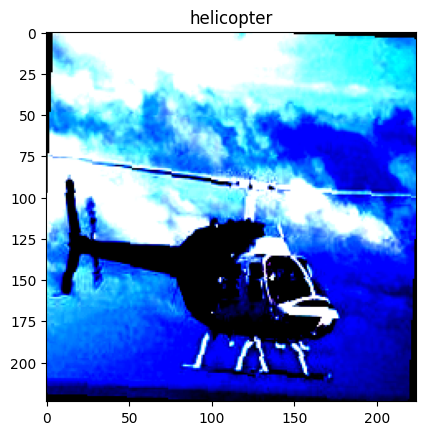

In [25]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


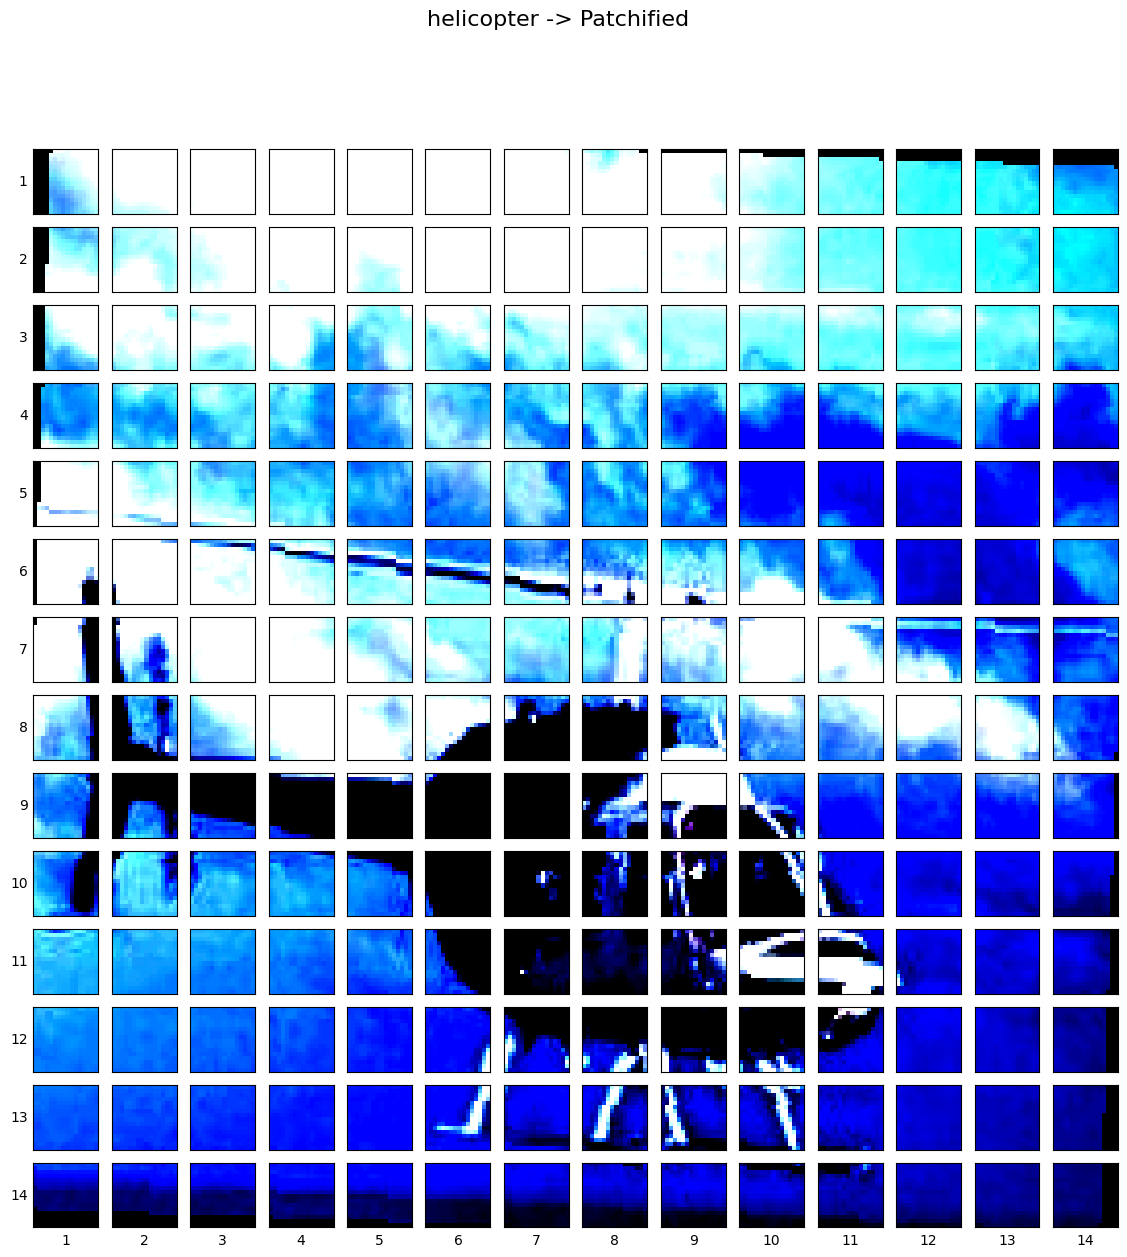

In [26]:
image_permuted = image.permute(1, 2, 0)
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [ ]:
# let's implement patching as an actual pytorch layer inside the model

In [28]:
from torch import nn
patch_size=16

conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

In [29]:
image_conv = conv2d(image)

print(image.shape)
print(image_conv.shape)

torch.Size([3, 224, 224])
torch.Size([768, 14, 14])


In [30]:
flatten = nn.Flatten(start_dim=1, end_dim=2)
image_conv_flattened = flatten(image_conv)

print(image_conv_flattened.shape)

torch.Size([768, 196])


In [ ]:
image_conv = conv2d(image.unsqueeze(0))
print(image_conv.shape)

torch.Size([1, 768, 14, 14])


In [ ]:
flatten = nn.Flatten(start_dim=2,
                      end_dim=3)
image_conv_flattened = flatten(image_conv)

print(image_conv_flattened.shape)

torch.Size([1, 768, 196])


In [34]:
# get flattened image patch embeddings in right shape
image_conv_flattened.permute(0,2,1).shape # [batch_size, num_patches, embedding_size]

torch.Size([1, 196, 768])

In [35]:
# let's create a layer with the whole code

In [36]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels: int=3,
               embedding_dim: int=768,
               patch_size: int=16):
    super().__init__()
    # create a layer to turn an image into patches
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)
    # create a layer to flatten the patch feature maps into a single dimension
    self.flatten = nn.Flatten(start_dim=2, end_dim=3)

  def forward(self, x):
    x_patcher = self.patcher(x)
    x_flattened = self.flatten(x_patcher)
    # make sure the output shape has the right order
    return x_flattened.permute(0,2,1)

In [ ]:
patchify = PatchEmbedding()

In [38]:
image.unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [ ]:
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [40]:
# let's try that with a random image

In [ ]:
random_input_image = (1, 3, 224, 224)

summary(PatchEmbedding(),
        input_size=random_input_image,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]          [1, 196, 768]             --                        True
├─Conv2d (patcher)                       [1, 3, 224, 224]          [1, 768, 14, 14]          590,592                   True
├─Flatten (flatten)                      [1, 768, 14, 14]          [1, 768, 196]             --                        --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [44]:
# let's create token embeddings

In [45]:
print(patch_embedded_image)

tensor([[[-0.7140,  0.6241, -2.0186,  ..., -0.5923, -1.4659,  0.6242],
         [ 0.4613, -0.7930, -0.7939,  ..., -0.6320, -1.4000, -0.2458],
         [ 0.5363, -0.6764, -0.8852,  ..., -0.6974, -1.4691, -0.2883],
         ...,
         [-0.0989, -0.3179, -0.4116,  ...,  0.0790, -0.8550,  0.2253],
         [-0.1490, -0.2615, -0.4333,  ...,  0.0984, -0.9122,  0.2931],
         [ 0.0092,  0.3680,  0.2123,  ...,  0.0395, -0.1469,  0.2753]]],
       grad_fn=<PermuteBackward0>)


In [46]:
print(patch_embedded_image.shape)

torch.Size([1, 196, 768])


In [47]:
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), requires_grad=True)
print(class_token.shape)

torch.Size([1, 1, 768])


In [48]:
class_token[:, :, :10]

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)

In [49]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image), dim=1)
patch_embedded_image_with_class_embedding

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7140,  0.6241, -2.0186,  ..., -0.5923, -1.4659,  0.6242],
         [ 0.4613, -0.7930, -0.7939,  ..., -0.6320, -1.4000, -0.2458],
         ...,
         [-0.0989, -0.3179, -0.4116,  ...,  0.0790, -0.8550,  0.2253],
         [-0.1490, -0.2615, -0.4333,  ...,  0.0984, -0.9122,  0.2931],
         [ 0.0092,  0.3680,  0.2123,  ...,  0.0395, -0.1469,  0.2753]]],
       grad_fn=<CatBackward0>)

In [50]:
patch_embedded_image_with_class_embedding.shape

torch.Size([1, 197, 768])

In [51]:
# let's create position embedding

In [52]:
patch_embedded_image_with_class_embedding

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7140,  0.6241, -2.0186,  ..., -0.5923, -1.4659,  0.6242],
         [ 0.4613, -0.7930, -0.7939,  ..., -0.6320, -1.4000, -0.2458],
         ...,
         [-0.0989, -0.3179, -0.4116,  ...,  0.0790, -0.8550,  0.2253],
         [-0.1490, -0.2615, -0.4333,  ...,  0.0984, -0.9122,  0.2931],
         [ 0.0092,  0.3680,  0.2123,  ...,  0.0395, -0.1469,  0.2753]]],
       grad_fn=<CatBackward0>)

In [53]:
number_of_patches = int((height * width) / patch_size**2)
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension), requires_grad=True)
print(position_embedding[:, :10, :10])
print(position_embedding.shape)

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
torch.Size([1, 197, 768])


In [ ]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(patch_and_position_embedding.shape)

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.2860,  1.6241, -1.0186,  ...,  0.4077, -0.4659,  1.6242],
         [ 1.4613,  0.2070,  0.2061,  ...,  0.3680, -0.4000,  0.7542],
         ...,
         [ 0.9011,  0.6821,  0.5884,  ...,  1.0790,  0.1450,  1.2253],
         [ 0.8510,  0.7385,  0.5667,  ...,  1.0984,  0.0878,  1.2931],
         [ 1.0092,  1.3680,  1.2123,  ...,  1.0395,  0.8531,  1.2753]]],
       grad_fn=<AddBackward0>)
torch.Size([1, 197, 768])


In [55]:
# let's try everything together

In [56]:
patch_size = 16

print(f"image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"input shape: {x.shape}")

patch_embedding_layer = PatchEmbedding(in_channels=3, patch_size=patch_size, embedding_dim=768)

patch_embedding = patch_embedding_layer(x)
print(f"patching embedded shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size, 1, embedding_dimension), requires_grad=True)

print(f"class token shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)

print(f"patch embedding class token size: {patch_embedding_class_token.shape}")

number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.randn(1, number_of_patches+1, embedding_dimension), requires_grad=True)

print(f"position embedding shape: {position_embedding.shape}")

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"patchified, class and position embedded image: {patch_and_position_embedding.shape}")

image tensor shape: torch.Size([3, 224, 224])
input shape: torch.Size([1, 3, 224, 224])
patching embedded shape: torch.Size([1, 196, 768])
class token shape: torch.Size([1, 1, 768])
patch embedding class token size: torch.Size([1, 197, 768])
position embedding shape: torch.Size([1, 197, 768])
patchified, class and position embedded image: torch.Size([1, 197, 768])


In [58]:
# let's move onto to the multi head attention

In [ ]:
class MultiheadSelfAttentionBlock(nn.Module):
  def __init__(self,
               embedding_dim:int=768,
               num_heads:int=12,
               attn_dropout:float=0):
    super().__init__()
    # create the norm layer (LN)
    self.layernorm = nn.LayerNorm(normalized_shape=embedding_dim)
    # create the multi-head attention layer (MSA)
    self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                num_heads=num_heads,
                                                dropout=attn_dropout,
                                                batch_first=True)

  def forward(self, x):
    x = self.layernorm(x)
    attn_output, _ = self.multihead_attn(query=x,
                                         key=x,
                                         value=x,
                                         need_weights=False)
    return attn_output


In [ ]:
multihead_self_attention_block = MultiheadSelfAttentionBlock(embedding_dim=768,
                                                             num_heads=12)

patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"patch and position embedding shape: {patch_and_position_embedding.shape}")
print(f"patched_image_through_msa_block shsape: {patched_image_through_msa_block.shape}")

patch and position embedding shape: torch.Size([1, 197, 768])
patched_image_through_msa_block shsape: torch.Size([1, 197, 768])


In [61]:
patch_and_position_embedding

tensor([[[-0.8574,  0.1576, -1.2157,  ...,  1.4656,  0.8455, -1.5499],
         [ 1.5944, -3.2753,  0.3253,  ...,  1.3529,  1.2862, -1.2100],
         [-2.5196, -0.1928, -0.6540,  ..., -0.2186,  1.0061, -0.6262],
         ...,
         [-0.4279, -1.6804, -0.4078,  ...,  2.6918,  0.2474,  1.1708],
         [ 0.8016, -1.3176,  2.5557,  ...,  1.2366,  2.4510, -1.2676],
         [ 3.2165, -2.0783, -0.4534,  ...,  0.6569,  0.9129,  0.9183]]],
       grad_fn=<AddBackward0>)

In [62]:
patched_image_through_msa_block

tensor([[[ 0.0029,  0.1646,  0.0848,  ..., -0.3086,  0.0173,  0.1204],
         [ 0.0401,  0.2156,  0.0717,  ..., -0.3177, -0.0038,  0.1161],
         [ 0.0436,  0.1435,  0.0357,  ..., -0.3340,  0.0050,  0.0372],
         ...,
         [ 0.0770,  0.1278,  0.0543,  ..., -0.2937,  0.0627,  0.1603],
         [ 0.0106,  0.1495,  0.0465,  ..., -0.3209,  0.0202,  0.1422],
         [ 0.0459,  0.1433,  0.1120,  ..., -0.2949,  0.0157,  0.1137]]],
       grad_fn=<TransposeBackward0>)

In [ ]:
# let's move onto to the mlp block

In [ ]:
class MLPBlock(nn.Module):
    def __init__(self,
                embedding_dim:int=768,
                mlp_size:int=3072,
                dropout:float=0.1):
      super().__init__()
      # create the norm layer (LN)
      self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
      # create the multilayer perceptron (MLP) layer(s)
      self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dim,
                  out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(p=dropout)
      )

    def forward(self, x):
      x = self.layer_norm(x)
      x = self.mlp(x)
      return x

In [ ]:
mlp_block = MLPBlock(embedding_dim=768,
                     mlp_size=3072,
                     dropout=0.1)

patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"patched_image_through_msa_block shape: {patched_image_through_msa_block.shape}")
print(f"patched_image_through_mlp_block shape: {patched_image_through_mlp_block.shape}")

patched_image_through_msa_block shape: torch.Size([1, 197, 768])
patched_image_through_mlp_block shape: torch.Size([1, 197, 768])


In [66]:
patched_image_through_msa_block

tensor([[[ 0.0029,  0.1646,  0.0848,  ..., -0.3086,  0.0173,  0.1204],
         [ 0.0401,  0.2156,  0.0717,  ..., -0.3177, -0.0038,  0.1161],
         [ 0.0436,  0.1435,  0.0357,  ..., -0.3340,  0.0050,  0.0372],
         ...,
         [ 0.0770,  0.1278,  0.0543,  ..., -0.2937,  0.0627,  0.1603],
         [ 0.0106,  0.1495,  0.0465,  ..., -0.3209,  0.0202,  0.1422],
         [ 0.0459,  0.1433,  0.1120,  ..., -0.2949,  0.0157,  0.1137]]],
       grad_fn=<TransposeBackward0>)

In [67]:
patched_image_through_mlp_block

tensor([[[-0.3852,  0.0011,  0.1462,  ...,  0.0362, -0.2848,  0.4154],
         [-0.5644,  0.1911,  0.2216,  ...,  0.1137, -0.1951,  0.5485],
         [-0.5019,  0.1652, -0.0097,  ...,  0.1919, -0.1950,  0.3380],
         ...,
         [-0.6264,  0.0909,  0.0471,  ..., -0.0793, -0.1429,  0.4479],
         [-0.6748,  0.2140,  0.0000,  ..., -0.0320, -0.3061,  0.2823],
         [-0.4694,  0.0317,  0.0076,  ...,  0.0492, -0.3446,  0.4761]]],
       grad_fn=<MulBackward0>)

In [68]:
# let's put everything together and create a transformer

In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 mlp_size:int=3072,
                 mlp_dropout:float=0.1,
                 attn_dropout:float=0):
      super().__init__()
      self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    attn_dropout=attn_dropout)
      self.mlp_block =  MLPBlock(embedding_dim=embedding_dim,
                                  mlp_size=mlp_size,
                                  dropout=mlp_dropout)

    def forward(self, x):
      x =  self.msa_block(x) + x
      x = self.mlp_block(x) + x

      return x

In [ ]:
transformer_encoder_block = TransformerEncoderBlock()

summary(model=transformer_encoder_block,
         input_size=(1, 197, 768),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layernorm)                       [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [ ]:
# we could have created the transformer this way, which looks like a very easy way but we couldn't understand what is going on
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768,
                                                             nhead=12,
                                                             dim_feedforward=3072,
                                                             dropout=0.1,
                                                             activation="gelu",
                                                             batch_first=True,
                                                             norm_first=True)


In [72]:
# ok let's put everything together and create a vision transformer

In [ ]:
class ViT(nn.Module):
  def __init__(self,
                patch_size:int=16,
                img_size:int=224,
                in_channels:int=3,
                num_transformer_layers:int=12,
                embedding_dim:int=768,
                num_heads:int=12,
                attn_dropout:float=0,
                mlp_size:int=3072,
                mlp_dropout:float=0.1,
                num_classes:int=101
                ):
    super().__init__()

    self.num_patches = (img_size * img_size) // patch_size**2

    self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim), requires_grad=True)

    self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim), requires_grad=True)

    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                        patch_size=patch_size,
                                        embedding_dim=embedding_dim)

    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                      num_heads=num_heads,
                                                                      mlp_size=mlp_size,
                                                                      mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

    self.classifier = nn.Sequential(
    nn.LayerNorm(normalized_shape=embedding_dim),
    nn.Linear(in_features=embedding_dim,
              out_features=num_classes)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size, -1, -1)

    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = self.position_embedding + x
    x = self.transformer_encoder(x)
    x = self.classifier(x[:, 0])

    return x


In [75]:
# let's get our training code

In [76]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [77]:
vit = ViT(num_classes=len(class_names)).to(device)

optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             weight_decay=0.3)
loss_fn = torch.nn.CrossEntropyLoss()

results = train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

Epoch: 1 | train_loss: 4.5497 | train_acc: 0.0768 | test_loss: 4.2911 | test_acc: 0.0861
Epoch: 2 | train_loss: 4.2623 | train_acc: 0.0894 | test_loss: 4.2519 | test_acc: 0.0861
Epoch: 3 | train_loss: 4.2998 | train_acc: 0.0895 | test_loss: 4.2774 | test_acc: 0.0861
Epoch: 4 | train_loss: 4.2364 | train_acc: 0.0916 | test_loss: 4.2162 | test_acc: 0.0861
Epoch: 5 | train_loss: 4.2243 | train_acc: 0.0955 | test_loss: 4.2371 | test_acc: 0.0861
Epoch: 6 | train_loss: 4.2173 | train_acc: 0.0925 | test_loss: 4.2118 | test_acc: 0.0861
Epoch: 7 | train_loss: 4.2192 | train_acc: 0.0925 | test_loss: 4.2062 | test_acc: 0.1003
Epoch: 8 | train_loss: 4.2155 | train_acc: 0.0946 | test_loss: 4.2190 | test_acc: 0.0861
Epoch: 9 | train_loss: 4.2152 | train_acc: 0.0892 | test_loss: 4.1972 | test_acc: 0.0861
Epoch: 10 | train_loss: 4.2149 | train_acc: 0.0915 | test_loss: 4.2017 | test_acc: 0.1003


In [79]:
# since we are using less data for training, less epochs and everything we do not have a very good result
# let's see what happens if we traing this the right way by using the weights that are pretrained for us

In [ ]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

In [81]:
pretrained_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [82]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [83]:
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

pretrained_vit_results = train(model=pretrained_vit,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=5,
                                      device=device)

Epoch: 1 | train_loss: 1.0820 | train_acc: 0.8263 | test_loss: 0.3289 | test_acc: 0.9184
Epoch: 2 | train_loss: 0.2259 | train_acc: 0.9466 | test_loss: 0.2328 | test_acc: 0.9381
Epoch: 3 | train_loss: 0.1360 | train_acc: 0.9659 | test_loss: 0.2186 | test_acc: 0.9352
Epoch: 4 | train_loss: 0.1064 | train_acc: 0.9722 | test_loss: 0.1930 | test_acc: 0.9443
Epoch: 5 | train_loss: 0.0784 | train_acc: 0.9819 | test_loss: 0.1850 | test_acc: 0.9437


In [84]:
# as seen it is much more accurate with a proper training, we didn't even need 10 epochs

In [85]:
# let's find a few images online and try with them

In [86]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [ ]:
thy_path = "./dataset/thy.jpg"

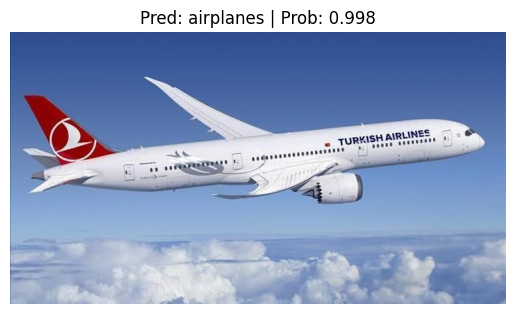

In [88]:
transform_predict(model=pretrained_vit, image_path = thy_path, class_names=class_names, device=device)

In [ ]:
puma_path = "./dataset/puma.jpg"

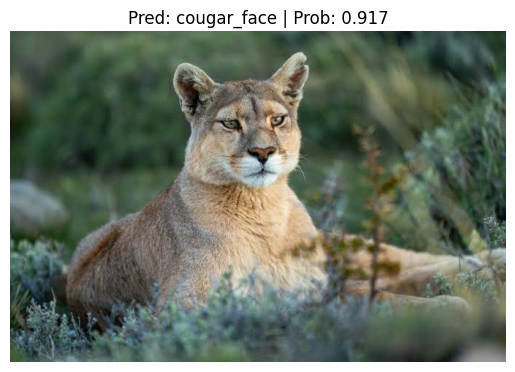

In [90]:
transform_predict(model=pretrained_vit, image_path = puma_path, class_names=class_names, device=device)